# VAERS COVID-19 Adverse Event Clustering

## Overview
Unsupervised clustering of VAERS COVID-19 adverse event reports to discover natural symptom phenotypes without relying on predefined outcome labels.

**Analysis pipeline:**
1. **Setup & Imports** 
2. **Load Data** 
3. **Load Precomputed Comorbidity Indicators** 
4. **Symptom Text Preprocessing** 
5. **TF-IDF + LSA** 
7. **Stability Analysis** 
8. **Final Clustering** 
9. **Cluster Interpretation** 
10. **Cluster Characterization** 
11. **Export** 

## 1. Setup & Imports

In [5]:
# ============================================================
# 1. SETUP
# ============================================================

import os
import re
import sys
import json
import math
import warnings
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer, OneHotEncoder
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

import scipy.sparse as sp

warnings.filterwarnings("ignore")

print("Python executable:", sys.executable)
print("Python version:", sys.version.split()[0])
print("Pandas version:", pd.__version__)

Python executable: /Users/ariellerothman/Desktop/Sperm Cell Analysis/.venv/bin/python
Python version: 3.12.10
Pandas version: 2.2.3


## 2. Load Data

Read the cleaned VAERS dataset produced by `Data preparation.ipynb`. The notebook will try `Outputs/df_clean_imputed.csv` first, then `Outputs/df_clean_engineered.csv` as fallback.

In [ ]:
# 2. LOAD DATA
from pathlib import Path

HERE = Path().resolve()  # project root (the folder containing this notebook)
OUTDIR = str(HERE / "Outputs")
os.makedirs(OUTDIR, exist_ok=True)

candidate_paths = [
    str(HERE / "Outputs" / "df_clean_imputed.csv"),
    str(HERE / "Outputs" / "df_clean_engineered.csv"),
]

data_path = next((p for p in candidate_paths if os.path.exists(p)), None)
if data_path is None:
    raise FileNotFoundError(
        "Expected one of these files but none were found:\n" + "\n".join(candidate_paths)
    )

df_clean = pd.read_csv(data_path, low_memory=False)

print("Dataset loaded:")
print(f"Path:  {data_path}")
print(f"Shape: {df_clean.shape}")

Dataset loaded:
Shape: (986096, 42)

Columns: ['VAERS_ID', 'DIED', 'L_THREAT', 'ER_VISIT', 'ER_ED_VISIT', 'HOSPITAL', 'DISABLE', 'BIRTH_DEFECT', 'SERIOUS', 'AGE_YRS', 'HOSPDAYS', 'NUMDAYS', 'ONSET_INTERVAL', 'RECVDATE', 'VAX_DATE', 'ONSET_DATE', 'DATEDIED', 'SEX', 'STATE', 'VAX_TYPE', 'SYMPTOM_TEXT', 'LAB_DATA', 'OTHER_MEDS', 'CUR_ILL', 'HISTORY', 'PRIOR_VAX', 'ALLERGIES', 'MAX_DOSE', 'DOSE_COUNT', 'MULTI_DOSE', 'UNKNOWN_DOSE', 'MULTI_MANUFACTURER', 'MANU__JANSSEN', 'MANU__MODERNA', 'MANU__NOVAVAX', 'MANU__PFIZER\\BIONTECH', 'MANU__UNKNOWN MANUFACTURER', 'YEAR', 'MONTH', 'NUMDAYS_MISSING', 'ONSET_INTERVAL_MISSING', 'AGE_YRS_MISSING']

Data types:
VAERS_ID                        int64
DIED                            int64
L_THREAT                        int64
ER_VISIT                        int64
ER_ED_VISIT                     int64
HOSPITAL                        int64
DISABLE                         int64
BIRTH_DEFECT                    int64
SERIOUS                         int64
AGE

## 3. Load Comorbidity Indicator Columns

In [ ]:
# ============================================================
# 3. LOAD PRECOMPUTED COMORBIDITY INDICATORS
# ============================================================

import os
import pandas as pd

from pathlib import Path
HERE   = Path().resolve()  # project root
OUTDIR = str(HERE / "Outputs")
os.makedirs(OUTDIR, exist_ok=True)

COMORB_PATH = str(HERE / "Outputs" / "comorbidity_indicators.csv")

# Detect currently available indicator columns
existing_indicator_cols = [
    c for c in df_clean.columns
    if "__" in c or c.endswith("_MISSING")
]

print(f"Existing indicator columns already in df_clean: {len(existing_indicator_cols)}")

if not os.path.exists(COMORB_PATH):
    raise FileNotFoundError(
        f"Comorbidity indicator file not found: {COMORB_PATH}\n"
        "Run Data preparation notebook first to generate comorbidity_indicators.csv."
    )

comorb_df = pd.read_csv(COMORB_PATH, low_memory=False)

if "VAERS_ID" not in comorb_df.columns:
    raise ValueError("comorbidity_indicators.csv must contain VAERS_ID for merging.")

indicator_cols = [
    c for c in comorb_df.columns
    if c != "VAERS_ID" and ("__" in c or c.endswith("_MISSING"))
]

missing_in_df = [c for c in indicator_cols if c not in df_clean.columns]

if not missing_in_df:
    print("All comorbidity indicator columns are already present. Skipping merge.")
else:
    merge_cols = ["VAERS_ID"] + missing_in_df

    # Use one row per VAERS_ID to prevent accidental row multiplication
    comorb_merge = comorb_df[merge_cols].drop_duplicates(subset=["VAERS_ID"])

    df_clean = df_clean.merge(
        comorb_merge,
        on="VAERS_ID",
        how="left",
        validate="m:1"
    )

    # Fill unmatched IDs as 0 and cast to compact integer dtype
    for c in missing_in_df:
        df_clean[c] = df_clean[c].fillna(0).astype("int8")

    print(f"Merged {len(missing_in_df)} indicator columns from comorbidity_indicators.csv")

final_indicator_cols = [
    c for c in df_clean.columns
    if "__" in c or c.endswith("_MISSING")
]

print(f"Total indicator columns now in df_clean: {len(final_indicator_cols)}")

print("Sample indicator columns:")print(final_indicator_cols[:20])

Saved CSV: /Users/ariellerothman/Desktop/Capstone/Outputs/comorbidity_indicators.csv shape: (986096, 63)
Parquet not saved (missing engine). CSV is saved and sufficient.
Parquet error: ImportError("Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.\nA suitable version of pyarrow or fastparquet is required for parquet support.\nTrying to import the above resulted in these errors:\n - Missing optional dependency 'pyarrow'. pyarrow is required for parquet support. Use pip or conda to install pyarrow.\n - Missing optional dependency 'fastparquet'. fastparquet is required for parquet support. Use pip or conda to install fastparquet.")

Indicator count: 62

Top indicators by prevalence:
                                    count  percent
PRIOR_VAX_MISSING                  940654   95.392
CUR_ILL_MISSING                    862779   87.494
ALLERGIES_MISSING                  743721   75.421
LAB_DATA_MISSING                   726769   73.702
OTHER_MEDS_MISSING                 

## 4. Symptom Text Preprocessing (Clustering-Optimized)

Clean and normalize `SYMPTOM_TEXT` for clustering. Two important differences from severity prediction preprocessing:

- **Administrative terms are removed** these terms appear in nearly every record and would dominate the TF-IDF feature space without contributing clinical signal
- **Outcome terms are kept** unlike severity prediction where these cause label leakage, here they may meaningfully separate phenotype clusters (e.g., cardiac arrest cluster vs. mild injection-site reaction cluster)

Records with fewer than 3 tokens after cleaning are excluded from clustering as near-empty narratives carry no useful signal.

In [ ]:
# ============================================================
# 4. SYMPTOM TEXT PREPROCESSING - CLUSTERING OPTIMIZED
# ============================================================
# Produces two text columns:
# - SYMPTOM_TEXT_CLEAN: base cleaning only
# - SYMPTOM_TEXT_CLEAN_CLUSTER: base cleaning + boilerplate removal
#
# Key difference from severity prediction:
# Outcome terms (hospitalization, death, ICU, serious) are intentionally
# kept here. In severity prediction they cause label leakage; for
# clustering, they help define clinically meaningful phenotype groups.

import re
import pandas as pd

# --------------------------------------------------
# Base text cleaning
# --------------------------------------------------
_url_re = re.compile(r"http\S+|www\S+|https\S+")
_email_re = re.compile(r"\S+@\S+")
_num_re = re.compile(r"\d+")
_keep_re = re.compile(r"[^a-z0-9\s\-]")
_ws2 = re.compile(r"\s+")

def clean_symptom_text(x):
    """
    Base-level cleaning for symptom text.
    Steps: lowercase, remove URLs/emails, replace digits with __NUM__,
    remove non-alphanumeric except hyphens, collapse whitespace.
    """
    if pd.isna(x) or x == "":
        return ""
    x = str(x).strip().lower()
    x = _url_re.sub(" ", x)
    x = _email_re.sub(" ", x)
    x = _num_re.sub(" __NUM__ ", x)
    x = _keep_re.sub(" ", x)
    x = _ws2.sub(" ", x).strip()
    return x

df_clean["SYMPTOM_TEXT_CLEAN"] = df_clean["SYMPTOM_TEXT"].apply(clean_symptom_text)

# --------------------------------------------------
# Clustering-specific administrative cleanup ONLY
# (No supervised leakage scrubbing)
#
# Removes: vaccine boilerplate, batch/lot info, report templates,
#          dosing language, and generic metadata terms that appear
#          across nearly all VAERS records and carry no discriminative
#          signal for grouping clinical phenotypes.
# Keeps:   all clinical/symptom terms, including outcome-related ones.
# --------------------------------------------------
admin_phrases = [
    # vaccine / manufacturer boilerplate
    r"\bcovid vaccine\b",
    r"\bcovid immunisation\b",
    r"\bmrna moderna\b",
    r"\bmoderna covid\b",
    r"\bpfizer[-\s]?biontech\b",
    r"\bbiontech\b",
    r"\bmoderna\b",
    r"\bpfizer\b",
    r"\bjanssen\b",
    r"\bnovavax\b",
    r"\bbnt\b",
    r"\bmrna\b",
    r"\bvaccine\b",
    r"\bcovid\b",

    # lot / batch / product fields
    r"\blot number\b",
    r"\bbatch number\b",
    r"\bbatch lot\b",
    r"\bvaccine lot\b",
    r"\blot\b",
    r"\bbatch\b",
    r"\bdosage form\b",
    r"\bform\b",
    r"\broute administration\b",
    r"\broute admin\b",
    r"\bunspecified route\b",
    r"\badministration\b",
    r"\bintramuscular\b",
    r"\bsuspension injection\b",
    r"\bsuspension\b",

    # generic case-report boilerplate
    r"\bpatient received\b",
    r"\bpatient experienced\b",
    r"\bsubject experienced\b",
    r"\bspontaneous report\b",
    r"\bmedical history\b",
    r"\bmedical information\b",
    r"\bfollowing information\b",
    r"\bdescribes occurrence\b",
    r"\boccurrence\b",
    r"\bprovided\b",
    r"\bcontactable\b",
    r"\bcase\b",
    r"\breporter\b",
    r"\breported\b",
    r"\breport\b",
    r"\boutcome\b",
    r"\bunknown date\b",
    r"\bdate patient\b",
    r"\bdate\b",

    # dosing / process boilerplate
    r"\bsingle dose\b",
    r"\bdose\b",
    r"\bbooster\b",
    r"\badmin\b",
    r"\bprophylactic vaccination\b",
    r"\breceived\b",
    r"\bgiven\b",
    r"\badministered\b",
    r"\buse\b",

    # recurring vague metadata terms
    r"\bunknown\b",
    r"\binformation\b",
    r"\bdescribed\b",
    r"\bdescribes\b",
    r"\boccurred\b",
    r"\bpatient\b",
    r"\bsubject\b",

    # concomitant / medication boilerplate
    # "concomitant medications" is standard VAERS report phrasing and appears
    # across all record types — it signals nothing clinical for clustering.
    r"\bconcomitant\b",
    r"\bmedication\b",
    r"\bmedications\b",
]

admin_regexes = [re.compile(p) for p in admin_phrases]

def remove_admin_terms(text):
    """
    Remove vaccine-brand boilerplate and administrative phrasing for clustering.

    Targets terms so common across all VAERS records (vaccine names, 'patient
    received', 'dose', 'concomitant', etc.) that they carry no discriminative
    signal for clustering. Unlike supervised leakage scrubbing, outcome terms
    are kept intentionally.

    Args:
        text: Cleaned symptom text string.

    Returns:
        Text with administrative/boilerplate terms removed.
    """
    if pd.isna(text) or text == "":
        return ""
    text = str(text).lower()
    for rgx in admin_regexes:
        text = rgx.sub(" ", text)
    text = _ws2.sub(" ", text).strip()
    return text

df_clean["SYMPTOM_TEXT_CLEAN_CLUSTER"] = (
    df_clean["SYMPTOM_TEXT_CLEAN"]
    .apply(remove_admin_terms)
)

# --------------------------------------------------
# Token count after cluster cleanup
# --------------------------------------------------
df_clean["CLUSTER_TOKEN_COUNT"] = (
    df_clean["SYMPTOM_TEXT_CLEAN_CLUSTER"]
    .str.split()
    .str.len()
    .fillna(0)
    .astype(int)
)

# Clustering-specific subset (rows with >= 3 tokens)
df_cluster = df_clean[df_clean["CLUSTER_TOKEN_COUNT"] >= 3].copy()

# --------------------------------------------------
# Summary
# --------------------------------------------------
print("=" * 60)
print("SYMPTOM TEXT PREPROCESSING - CLUSTERING OPTIMIZED")
print("=" * 60)
print(f"\nRows in full dataset:         {len(df_clean):,}")
print(f"Rows retained for clustering: {len(df_cluster):,}")
print(f"Rows dropped (sparse):        {len(df_clean) - len(df_cluster):,}")
print(f"\nBoilerplate REMOVED:")
print("  ✗ Vaccine brand names (Pfizer, Moderna, Janssen, etc.)")
print("  ✗ Lot/batch numbers, dosing/route language")
print("  ✗ Case-report template phrasing (patient received, administered, etc.)")
print("  ✗ Concomitant / medication boilerplate")
print(f"\nClinical signal KEPT:")
print("  ✓ Symptoms (fever, headache, chest pain, etc.)")
print("  ✓ Outcome terms (serious, hospital, death, ICU)")
print("  ✓ Comorbidity mentions (diabetes, asthma, etc.)")
print("=" * 60)

# --------------------------------------------------
# Save cleaned text variants
# --------------------------------------------------
df_clean[
    [
        "VAERS_ID",
        "SYMPTOM_TEXT",
        "SYMPTOM_TEXT_CLEAN",
        "SYMPTOM_TEXT_CLEAN_CLUSTER",
        "CLUSTER_TOKEN_COUNT"
    ]
].to_csv(
    f"{OUTDIR}/symptom_text_clean_variants_cluster_only.csv",
    index=False
)
print(f"\nSaved: symptom_text_clean_variants_cluster_only.csv")
print(f"Text fields available: {[c for c in df_clean.columns if 'SYMPTOM' in c or 'CLUSTER_TOKEN_COUNT' in c]}")

STEP 17: SYMPTOM TEXT PREPROCESSING - CLUSTERING OPTIMIZED

Rows in full dataset:        986,096
Rows retained for clustering: 955,355
Rows dropped (sparse):        30,741

Preprocessing removed:

Preprocessing KEPT (for pure symptom clustering):
  ✓ Clinical symptoms (fever, headache, chest pain, etc.)
  ✓ Outcome terms (serious, hospital, death, ICU)
  ✓ Comorbidity mentions (diabetes, asthma, etc.)

Saved: symptom_text_clean_variants_cluster_only.csv
Text fields available: ['SYMPTOM_TEXT', 'SYMPTOM_TEXT_CLEAN', 'SYMPTOM_TEXT_CLEAN_CLUSTER', 'CLUSTER_TOKEN_COUNT']


## 5. TF-IDF Vectorization & Dimensionality Reduction (LSA)

Vectorize `SYMPTOM_TEXT_CLEAN_CLUSTER` using TF-IDF (5,000 features, unigrams + bigrams, sublinear TF scaling, `min_df=10`), fitted only on the clustering-eligible rows. Reduce the sparse TF-IDF matrix to 200 dense LSA dimensions via Truncated SVD, then L2-normalize.

In [ ]:
# ============================================================
# 5. TF-IDF + LSA ON CLUSTER-CLEANED TEXT
# ============================================================
# Preserve row-index mapping for safe label assignment later.

cluster_indices = df_cluster.index.values
np.save(f"{OUTDIR}/cluster_row_indices.npy", cluster_indices)

tfidf_cluster = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=10,
    max_df=0.9,
    stop_words="english",
    sublinear_tf=True,
    norm="l2",
    strip_accents="unicode",
    token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z\-]+\b|__NUM__"
)

# Use df_cluster (rows with >= 3 tokens), not df_clean
X_tfidf_cluster = tfidf_cluster.fit_transform(df_cluster["SYMPTOM_TEXT_CLEAN_CLUSTER"])
print("TF-IDF shape:", X_tfidf_cluster.shape)
print(f"Fit on {len(df_cluster)} rows with >= 3 tokens")

# Save TF-IDF + vocabulary
sp.save_npz(f"{OUTDIR}/symptom_text_tfidf_cluster_cleaned.npz", X_tfidf_cluster)
pd.DataFrame({"term": tfidf_cluster.get_feature_names_out()}).to_csv(
    f"{OUTDIR}/tfidf_vocabulary_cluster_cleaned.csv", index=False
)

# SVD / LSA
svd_cluster = TruncatedSVD(n_components=200, random_state=42)
X_lsa_cluster = svd_cluster.fit_transform(X_tfidf_cluster)
X_lsa_cluster = Normalizer(copy=False).fit_transform(X_lsa_cluster)

np.save(f"{OUTDIR}/symptom_text_lsa_200d_cluster_cleaned.npy", X_lsa_cluster)
np.save(f"{OUTDIR}/svd_components_200d_cluster_cleaned.npy", svd_cluster.components_)

print(f"X_lsa_cluster shape: {X_lsa_cluster.shape}")
print("Cluster indices saved for alignment")

TF-IDF shape: (955355, 5000)
Fit on 955355 rows with >= 3 tokens
X_lsa_cluster shape: (955355, 200)
Cluster indices saved for alignment in Step 21


## 6. Cluster Count Selection: Elbow + Silhouette

Evaluate k ∈ {5, 8, 10, 12, 15} using two complementary metrics:

- **Inertia (elbow method)**
- **Silhouette score** 

Set `best_k` in the stability cell based on these results before proceeding.

k= 5 | silhouette=0.0295 | inertia=8.41e+05
k= 8 | silhouette=0.0338 | inertia=8.12e+05
k=10 | silhouette=0.0416 | inertia=7.94e+05
k=12 | silhouette=0.0424 | inertia=7.80e+05
k=15 | silhouette=0.0544 | inertia=7.58e+05


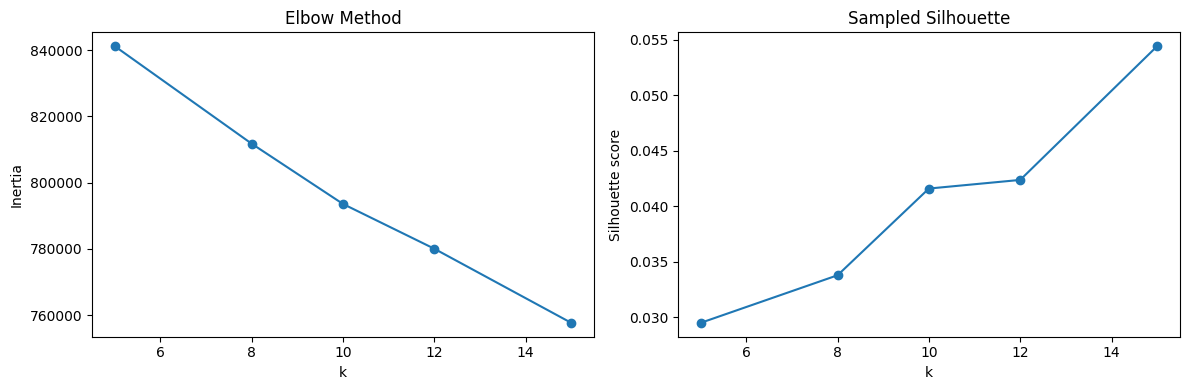

In [ ]:
# ============================================================
# 6. CLUSTER COUNT SELECTION: ELBOW + SAMPLED SILHOUETTE
# ============================================================

rng = np.random.default_rng(42)
silhouette_sample_size = 20000
silhouette_idx = rng.choice(X_lsa_cluster.shape[0], size=silhouette_sample_size, replace=False)
X_sil = X_lsa_cluster[silhouette_idx]

k_values = [5, 8, 10, 12, 15]
elbow_results = []

for k in k_values:
    km = MiniBatchKMeans(
        n_clusters=k,
        random_state=42,
        batch_size=10000,
        n_init=3
    )
    labels_full = km.fit_predict(X_lsa_cluster)
    labels_sil = labels_full[silhouette_idx]
    sil = silhouette_score(X_sil, labels_sil)

    elbow_results.append({
        "k": k,
        "inertia": km.inertia_,
        "silhouette": sil
    })

    print(f"k={k:2d} | silhouette={sil:.4f} | inertia={km.inertia_:.2e}")

elbow_df = pd.DataFrame(elbow_results)
elbow_df.to_csv(f"{OUTDIR}/cluster_selection_metrics_cluster_cleaned.csv", index=False)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(elbow_df["k"], elbow_df["inertia"], marker="o")
ax[0].set_title("Elbow Method")
ax[0].set_xlabel("k")
ax[0].set_ylabel("Inertia")
ax[1].plot(elbow_df["k"], elbow_df["silhouette"], marker="o")
ax[1].set_title("Sampled Silhouette")
ax[1].set_xlabel("k")
ax[1].set_ylabel("Silhouette score")
plt.tight_layout()
plt.show()

## 7. Stability Analysis

Fit K-Means with the chosen `best_k` across 5 different random seeds on a 100,000-row subsample. Compute pairwise Adjusted Rand Index (ARI) to measure how consistently the same cluster structure emerges regardless of initialization.

In [ ]:
# ============================================================
# 7. STABILITY ANALYSIS (ARI ACROSS RANDOM SEEDS)
# ============================================================

# Set chosen k here after reviewing elbow + silhouette
best_k = 8

stability_sample_size = min(20000, X_lsa_cluster.shape[0])
stability_idx = rng.choice(X_lsa_cluster.shape[0], size=stability_sample_size, replace=False)
X_stability = X_lsa_cluster[stability_idx]

seeds = [1, 7, 21, 42, 88]
labels_by_seed = {}

for seed in seeds:
    km = MiniBatchKMeans(
        n_clusters=best_k,
        random_state=seed,
        batch_size=10000,
        n_init=3
    )
    labels_by_seed[seed] = km.fit_predict(X_stability)

stability_results = []
for i, seed_a in enumerate(seeds):
    for seed_b in seeds[i+1:]:
        ari = adjusted_rand_score(labels_by_seed[seed_a], labels_by_seed[seed_b])
        stability_results.append({"seed_a": seed_a, "seed_b": seed_b, "ARI": ari})

stability_df = pd.DataFrame(stability_results)
print(stability_df)
print("\nMean ARI:", stability_df["ARI"].mean())

stability_df.to_csv(f"{OUTDIR}/cluster_stability_ari_cluster_cleaned.csv", index=False)

   seed_a  seed_b       ARI
0       1       7  0.433252
1       1      21  0.457860
2       1      42  0.411774
3       1      88  0.751655
4       7      21  0.495183
5       7      42  0.426743
6       7      88  0.474293
7      21      42  0.459517
8      21      88  0.443869
9      42      88  0.391653

Mean ARI: 0.4745799228929858


## 8. Final Clustering Model

Fit the final K-Means on the full LSA-reduced dataset (`X_lsa_cluster`) using `best_k` and `n_init=5`. Cluster labels are mapped back to `df_clean` using the saved row indices. Rows excluded from clustering (near-empty narratives) receive `NaN` for the `CLUSTER` column.

In [ ]:
# ============================================================
# 8. FINAL CLUSTERING MODEL ON FULL DATASET
# ============================================================

# Load the saved cluster indices (rows that had >= 3 tokens)
cluster_indices = np.load(f"{OUTDIR}/cluster_row_indices.npy")

final_km = MiniBatchKMeans(
    n_clusters=best_k,
    random_state=42,
    batch_size=10000,
    n_init=5
)

cluster_labels_subset = final_km.fit_predict(X_lsa_cluster)

# Initialize CLUSTER column as NaN in full dataset
df_clean["CLUSTER"] = np.nan

# Map labels back using saved indices
df_clean.loc[cluster_indices, "CLUSTER"] = cluster_labels_subset

print(f"\nClustered rows: {df_clean['CLUSTER'].notna().sum()}")
print(f"Unclustered (sparse): {df_clean['CLUSTER'].isna().sum()}\n")

cluster_sizes = df_clean["CLUSTER"].value_counts().sort_index()
print(cluster_sizes)
(cluster_sizes / df_clean["CLUSTER"].notna().sum()).rename("proportion").to_csv(
    f"{OUTDIR}/cluster_sizes_cluster_cleaned.csv"
)


Clustered rows: 955355
Unclustered (sparse): 30741

CLUSTER
0.0    122315
1.0    101215
2.0     79493
3.0    248134
4.0     41656
5.0     85569
6.0    196541
7.0     80432
Name: count, dtype: int64


## 9. Cluster Interpretation: Top Terms

Reconstruct approximate TF-IDF centroid weights by projecting K-Means cluster centroids from LSA space back to term space. 

In [ ]:
# ============================================================
# 9. CLUSTER INTERPRETATION: RECONSTRUCTED TOP TERMS
# ============================================================

feature_names = pd.read_csv(f"{OUTDIR}/tfidf_vocabulary_cluster_cleaned.csv")["term"].values
svd_components = np.load(f"{OUTDIR}/svd_components_200d_cluster_cleaned.npy")

reconstructed_centroids = final_km.cluster_centers_ @ svd_components

top_terms_rows = []
for cluster_id in range(best_k):
    centroid = reconstructed_centroids[cluster_id]
    top_idx = np.argsort(centroid)[::-1][:20]
    top_terms = feature_names[top_idx]

    print(f"\nCluster {cluster_id} top terms:")
    print(", ".join(top_terms))

    for rank, term in enumerate(top_terms, start=1):
        top_terms_rows.append({"cluster": cluster_id, "rank": rank, "term": term})

top_terms_df = pd.DataFrame(top_terms_rows)
top_terms_df.to_csv(f"{OUTDIR}/cluster_top_terms_cluster_cleaned.csv", index=False)


Cluster 0 top terms:
vaccination, spontaneous, action taken, route, action, time, concomitant, spontaneous consumer, taken, treatment, pain, included, consumer, female, year-old, mar, medications, site, vaccination site, arm

Cluster 1 top terms:
minutes, pt, felt, feeling, called, bp, symptoms, ems, home, benadryl, better, dizzy, stated, started, hr, went, throat, mg, receiving, water

Cluster 2 top terms:
single, unspecified, immunisation, consumer, medications, concomitant medications, concomitant, non, relevant, single immunisation, hcp, included, immunisation relevant, immunization, attempts, non-serious, follow-up attempts, non hcp, consumer non, follow-up

Cluster 3 top terms:
days, pain, left, right, chest, day, shot, started, symptoms, rash, second, weeks, heart, developed, severe, swelling, nd, week, dizziness, blood

Cluster 4 top terms:
prior, vaccination, prior vaccination, events, weeks, arm, receive, did, did receive, included, left, tested, diagnosed, vaccination teste

## 10. Cluster Characterization

Profile each cluster across clinical and demographic variables to understand what distinguishes the phenotype groups:

- **Seriousness rate** — proportion of `SERIOUS=1` within each cluster
- **Age** — mean and distributional summary
- **Sex** — proportion by gender
- **Manufacturer** — vaccine brand distribution across clusters
- **Comorbidities** — mean prevalence of each binary comorbidity indicator per cluster

In [ ]:
# ============================================================
# 10. CLUSTER CHARACTERIZATION
# ============================================================

# Cluster vs serious outcome
cluster_serious = pd.crosstab(df_clean["CLUSTER"], df_clean["SERIOUS"], normalize="index")
print("\nCluster vs SERIOUS")
print(cluster_serious)
cluster_serious.to_csv(f"{OUTDIR}/cluster_vs_serious_cluster_cleaned.csv")

# Cluster vs sex
if "SEX" in df_clean.columns:
    cluster_sex = pd.crosstab(df_clean["CLUSTER"], df_clean["SEX"], normalize="index")
    print("\nCluster vs SEX")
    print(cluster_sex)
    cluster_sex.to_csv(f"{OUTDIR}/cluster_vs_sex_cluster_cleaned.csv")

# Cluster vs age
if "AGE_YRS" in df_clean.columns:
    cluster_age = df_clean.groupby("CLUSTER")["AGE_YRS"].describe()
    print("\nCluster age summary")
    print(cluster_age)
    cluster_age.to_csv(f"{OUTDIR}/cluster_age_summary_cluster_cleaned.csv")

# Cluster vs manufacturer
manufacturer_cols = [c for c in df_clean.columns if c.startswith("MANU__")]
if manufacturer_cols:
    cluster_manu = df_clean.groupby("CLUSTER")[manufacturer_cols].mean()
    print("\nCluster vs manufacturer")
    print(cluster_manu)
    cluster_manu.to_csv(f"{OUTDIR}/cluster_vs_manufacturer_cluster_cleaned.csv")

# Cluster vs comorbidities
comorb_cols = [c for c in df_clean.columns if "__" in c and not c.startswith("MANU__")]
if comorb_cols:
    cluster_comorb = df_clean.groupby("CLUSTER")[comorb_cols].mean()
    print("\nCluster vs comorbidities (first 10 cols)")
    print(cluster_comorb.iloc[:, :10])
    cluster_comorb.to_csv(f"{OUTDIR}/cluster_vs_comorbidities_cluster_cleaned.csv")

# Cluster summary
cluster_summary = df_clean.groupby("CLUSTER").agg({
    "SERIOUS": "mean",
    "AGE_YRS": "mean",
    "VAERS_ID": "count"
}).rename(columns={"SERIOUS": "SERIOUS_RATE", "AGE_YRS": "MEAN_AGE", "VAERS_ID": "N"})

print("\nCluster summary")
print(cluster_summary)
cluster_summary.to_csv(f"{OUTDIR}/cluster_summary_cluster_cleaned.csv")


Cluster vs SERIOUS
SERIOUS         0         1
CLUSTER                    
0.0      0.922577  0.077423
1.0      0.704846  0.295154
2.0      0.906960  0.093040
3.0      0.763668  0.236332
4.0      0.858460  0.141540
5.0      0.990920  0.009080
6.0      0.938145  0.061855
7.0      0.229411  0.770589

Cluster vs SEX
SEX             F         M         U
CLUSTER                              
0.0      0.601956  0.264253  0.133791
1.0      0.683519  0.309516  0.006966
2.0      0.598139  0.291171  0.110689
3.0      0.650773  0.338696  0.010531
4.0      0.736076  0.255161  0.008762
5.0      0.465750  0.416860  0.117390
6.0      0.768461  0.224691  0.006848
7.0      0.506869  0.486591  0.006540

Cluster age summary
            count       mean        std   min   25%   50%   75%    max
CLUSTER                                                               
0.0      122315.0  55.810128  14.837144  0.08  51.0  51.0  66.0  109.0
1.0      101215.0  43.483201  19.664617  0.08  28.0  42.0  58.0  105.0

## 11. Export

Save the full dataset with cluster labels appended as `df_clean_with_clusters.csv`. This file is the input for the time series analysis notebook, which examines how cluster membership and seriousness rates evolve over the reporting period.

In [ ]:
# ============================================================
# 11. EXPORT FINAL CLUSTERED DATASET
# ============================================================
df_clean.to_csv(f"{OUTDIR}/df_clean_with_clusters.csv", index=False)
print("✓ Full clustered dataset saved for time series analysis")

✓ Full clustered dataset saved for time series analysis
